# ISYS2407 Information Systems Solutions & Design  
# Assignment 3: Exploratory Data Analysis  

#### Student Name: Lam Le 
#### Student Number: s4032582  
#### Dataset: personal-loan.csv  

---

### Purpose  
This notebook performs an **Exploratory Data Analysis (EDA)** on the *personal-loan.csv* dataset.  
The goal is to understand the characteristics of the bank’s customers and discover what factors influence their decision to accept a **Personal Loan** offer.  

The EDA will:
- Describe and clean the dataset so it can be used for modelling.  
- Explore patterns, trends, and relationships between customer features (such as Income, Education, and Credit Card spending) and the loan acceptance outcome.  
- Identify possible data issues like missing values or outliers.  
- Summarise meaningful insights that can guide predictive model development.  

---

### Outcome  
- A clean, well-understood dataset.  
- Clear insights into which customer characteristics drive Personal Loan acceptance.  
- Visualisations that summarise key relationships.  
- A foundation for accurate and ethical predictive modelling.

# 1 Dataset Overview & Structure  

### Purpose  
This section establishes a clear understanding of the dataset before deeper analysis.  
It confirms successful import, verifies data integrity, and ensures all variables are correctly structured for exploration and modelling.

### Method  
1. Import required libraries for analysis and visualisation.  
2. Load and preview the *personal-loan.csv* dataset.  
3. Inspect data types, missing values, and categorical fields.  
4. Convert human-readable values into machine-readable form.  
5. Produce summary statistics and logical groupings of variables.

### Outcome  
- Dataset successfully imported and verified.  
- Variables correctly typed and encoded for analysis.  
- Missing values handled and data cleaned for reliability.  
- Summary statistics generated, providing an overall picture of the data.  

Together, these steps prepare the dataset for **Exploratory Data Analysis (EDA)** in the next phase.


### 1.1 Import Libraries  

Load the essential Python libraries for **data analysis and visualisation**.  
These tools enable efficient exploration, cleaning, and pattern discovery throughout the project.

**Expected Outcome:**  
All core libraries (pandas, numpy, matplotlib, seaborn) are imported successfully and ready for use.

In [1]:
# 1.1 Import Libraries

# Basic data analysis and visualisation tools
import pandas as pd               # work with data tables (rows × columns)
import numpy as np                # mathematical and statistical functions
import matplotlib.pyplot as plt   # create charts and graphs
import seaborn as sns             # easier, prettier plots built on Matplotlib

# Optional: Auto-install packages if missing (useful for marking computers)
import sys, subprocess
for pkg in ['missingno', 'seaborn', 'matplotlib', 'pandas', 'numpy', 'scikit-learn']:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    
# Extra tools for advanced EDA
from sklearn.impute import SimpleImputer    # handle missing values professionally
import missingno as msno                   # visualise missing data patterns
import warnings                            # hide unnecessary system warnings

# Make charts look nice and outputs cleaner
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')  # nice, clean visual theme
pd.set_option('display.float_format', lambda x: '%.3f' % x)  # round decimals

# quick check to confirm successful import
print("All libraries imported successfully and ready to use!")


All libraries imported successfully and ready to use!


### 1.2 Load and Inspect Dataset  

Load the *personal-loan.csv* dataset, view its structure, and perform basic integrity checks.  
This step verifies that the data has been imported correctly and helps detect potential issues such as duplicate records or missing values before deeper analysis.

**Expected Outcome:**  
- Dataset successfully loaded into a pandas DataFrame.  
- Displayed structure (rows, columns) and sample records using `head()`.  
- Preliminary understanding of data completeness and consistency.  


In [2]:
# 1.2 Load and Inspect Dataset
# Load the CSV, check shape/preview, dtypes, duplicates, missingness, and target balance.

# Load the personal loan dataset from the local folder
# (make sure the CSV file is in the same directory as this notebook)
df = pd.read_csv('personal-loan.csv')

# Quick shape check – how many rows and columns?
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Preview the first few rows to get a sense of the data
display(df.head())

# Check data types and null values to understand structure
print("\n- Dataset Info -")
df.info()

# Quick look at duplicates (to ensure data integrity)
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows found: {dup_count}")

# Check how many missing values per column
print("\n- Missing Values by Column -")
print(df.isna().sum())

# Quick percentage of missing values – easier to interpret
missing_percent = (df.isna().mean() * 100).round(2)
print("\n- Percentage of Missing Values -")
print(missing_percent)

# Confirm target column exists and inspect balance
print("\n- Target Variable Preview (percent share) -")
print(df['personal_loan'].value_counts(normalize=True).mul(100).round(2))


Rows: 6000, Columns: 13


,customer_id,age,yrs_experience,family_size,education_level,income,mortgage_amt,credit_card_acct,credit_card_spend,share_trading_acct,fixed_deposit_acct,online_acct,personal_loan
0,3815,40.000,9.000,3.000,Graduate,60.000,0,yes,1.700,0,0,yes,no
1,5737,65.000,27.000,4.000,Advanced or Professional,36.000,90,no,0.000,0,0,yes,no
2,4209,61.000,3.000,2.000,Undergraduate,145.000,314,no,0.000,0,1,yes,yes
3,4734,29.000,14.000,1.000,Undergraduate,52.000,0,no,0.000,1,0,yes,no
4,2551,43.000,23.000,4.000,Graduate,33.000,0,no,0.000,0,0,yes,no



- Dataset Info -
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         6000 non-null   int64  
 1   age                 5620 non-null   float64
 2   yrs_experience      5636 non-null   float64
 3   family_size         5615 non-null   float64
 4   education_level     6000 non-null   object 
 5   income              5623 non-null   float64
 6   mortgage_amt        6000 non-null   int64  
 7   credit_card_acct    6000 non-null   object 
 8   credit_card_spend   6000 non-null   float64
 9   share_trading_acct  6000 non-null   int64  
 10  fixed_deposit_acct  6000 non-null   int64  
 11  online_acct         6000 non-null   object 
 12  personal_loan       6000 non-null   object 
dtypes: float64(5), int64(4), object(4)
memory usage: 609.5+ KB

Duplicate rows found: 0

- Missing Values by Column -
customer_id          

**Interpretation:**  
The dataset loaded successfully and contains **6,000 customer records and 13 features**.  
Each record represents one customer’s demographic, financial, and account information.  

Initial inspection shows:
- No duplicate rows were found, indicating good data integrity.  
- The columns `age`, `yrs_experience`, `family_size`, and `income` each have around **6% missing values**, which will need imputation later.  
- Data types are mixed: numerical (like income, credit_card_spend) and categorical (like education_level, credit_card_acct, online_acct).  
- The target variable `personal_loan` is **imbalanced**, with **15% of customers accepting** and **85% declining** the loan offer.  

These findings suggest the data is mostly clean and well-structured, but minor cleaning (handling missing values and converting Yes/No or text categories to numeric form) will be required before further analysis.


### 1.3 Convert Columns (Human Logic → Machine Logic)  

Convert text-based categories into numeric form so the dataset can be processed for analysis and modelling.  
Column names are standardised to lowercase, “yes/no” fields are mapped to 1/0, and *education_level* is encoded as an ordered variable (1–3).  

**Expected Outcome:**  
All categorical variables converted to numeric format and ready for statistical analysis.


In [3]:
# 1.3 Convert Columns (Human Logic → Machine Logic)
# This step converts text categories (like 'yes'/'no' or education levels)
# into numeric codes that Python can understand for statistical analysis.

# Make all column names lowercase for consistency
df.columns = df.columns.str.lower()

# Convert 'yes'/'no' columns to binary (1/0)
yes_no_cols = ['credit_card_acct', 'online_acct', 'personal_loan']

for col in yes_no_cols:
    df[col] = df[col].replace({'yes': 1, 'no': 0})

# Encode 'education_level' as ordered categories
# Assuming: Undergraduate < Graduate < Advanced/Professional
edu_map = {
    'Undergraduate': 1,
    'Graduate': 2,
    'Advanced or Professional': 3
}
df['education_level'] = df['education_level'].map(edu_map)

# Quick check of the updated columns
print("\n- Converted Columns Preview -")
display(df[['education_level', 'credit_card_acct', 'online_acct', 'personal_loan']].head())

# Confirm all dtypes now numerical where expected
print("\n- Data Types After Conversion -")
print(df.dtypes)



- Converted Columns Preview -


,education_level,credit_card_acct,online_acct,personal_loan
0,2,1,1,0
1,3,0,1,0
2,1,0,1,1
3,1,0,1,0
4,2,0,1,0



- Data Types After Conversion -
customer_id             int64
age                   float64
yrs_experience        float64
family_size           float64
education_level         int64
income                float64
mortgage_amt            int64
credit_card_acct        int64
credit_card_spend     float64
share_trading_acct      int64
fixed_deposit_acct      int64
online_acct             int64
personal_loan           int64
dtype: object


**Interpretation:**  
All categorical variables have been successfully converted into numeric format:  
- `credit_card_acct`, `online_acct`, and `personal_loan` were mapped as **1 = Yes**, **0 = No**.  
- `education_level` was encoded as an ordered scale (**1 = Undergraduate**, **2 = Graduate**, **3 = Advanced/Professional**).  
This ensures that all key features can be included in statistical and correlation analysis later.  


### 1.4 Handle Missing Values  

Identify and handle missing values to maintain complete and reliable data for analysis.  
This step ensures data integrity and prevents errors or biases in later stages.

**Expected Outcome:**  
All missing values detected and appropriately handled (e.g: removed or imputed), leaving a clean and consistent dataset.


In [4]:
# 1.4 Handle Missing Values
# About 6% of values are missing in 'age', 'yrs_experience', 'family_size', and 'income'.
# We'll impute (fill in) these missing values using two approaches:
# Basic method: fill with median (robust against outliers)
# Advanced: confirm using SimpleImputer from sklearn for professional reproducibility

# List of columns with missing data
missing_cols = ['age', 'yrs_experience', 'family_size', 'income']

# Basic imputation (median-based)
for col in missing_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

# Advanced step: Confirm and automate imputation pipeline using SimpleImputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df[missing_cols] = imputer.fit_transform(df[missing_cols])

# Quick validation – confirm no nulls remain
print("\n- Missing Values After Imputation -")
print(df[missing_cols].isna().sum())

# Preview imputed values (optional sanity check)
display(df[missing_cols].head())



- Missing Values After Imputation -
age               0
yrs_experience    0
family_size       0
income            0
dtype: int64


,age,yrs_experience,family_size,income
0,40.000,9.000,3.000,60.000
1,65.000,27.000,4.000,36.000
2,61.000,3.000,2.000,145.000
3,29.000,14.000,1.000,52.000
4,43.000,23.000,4.000,33.000


**Interpretation:**  
- All missing values in numerical columns (`age`, `yrs_experience`, `family_size`, and `income`) have been imputed using the **median** strategy.  
- This approach keeps the data stable by reducing the influence of outliers (common in income or age distributions).  
- Validation confirms that no missing values remain, ensuring the dataset is clean and consistent for further statistical and visual analysis.


### 1.5 Save the Cleaned Dataset  

Save a cleaned version of the dataset for use in later phases such as data exploration, modelling, and evaluation.  
Keeping a separate copy preserves the original data and ensures consistent results across notebooks.

**Expected Outcome:**  
A cleaned dataset file successfully saved (*personal_loan_clean.csv*) for future analysis.


In [5]:
# 1.5 Save the Cleaned Dataset
# Save the cleaned version so we can safely reuse it later (for modelling or visualisation notebooks).

# Define the filename
cleaned_file = "personal_loan_cleaned.csv"

# Save to CSV without the index column
df.to_csv(cleaned_file, index=False)

# Confirm that the file has been saved
import os
if cleaned_file in os.listdir():
    print(f"Cleaned dataset saved successfully as '{cleaned_file}'!")
else:
    print("Something went wrong — please check your save path.")


Cleaned dataset saved successfully as 'personal_loan_cleaned.csv'!


**Interpretation:**  
- The cleaned dataset was successfully saved as *personal_loan_cleaned.csv* in the same directory as this notebook.  
- This ensures a consistent, ready-to-use version for future analysis (data visualisation, correlation study, and predictive modelling).  
- Saving the cleaned version is a best practice in professional data workflows, it avoids repeating cleaning steps and ensures reproducibility across phases.

### 1.6 Summary Statistics & Data Overview  

Generate summary statistics to understand the dataset’s structure and feature characteristics.  
Review data shape, identify unique values, and group variables into logical categories: binary, small discrete, and continuous.

**Expected Outcome:**  
Clear overview of dataset dimensions, variable groupings, and basic descriptive statistics to guide further analysis.


In [6]:
# 1.6 Summary Statistics & Data Overview
# Goal: quick stats + clear grouping of variables for later EDA

# Unique counts per column (at a glance)
print("\n- Unique values per column-")
display(df.nunique().sort_values())

# Identify logical feature groups
id_cols = ['customer_id']
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

binary_cols = [c for c in numeric_cols if df[c].nunique() == 2]
small_discrete_cols = [c for c in numeric_cols if 2 < df[c].nunique() <= 10 and c not in id_cols]
continuous_cols = [c for c in numeric_cols if df[c].nunique() > 10 and c not in id_cols]

# Treat education_level as categorical/ordered even though it's stored as int
ordered_cats = ['education_level']

print("\n- Variable groups (logical) -")
print(f"Identifiers: {id_cols}")
print(f"Binary:      {binary_cols}")
print(f"Small discrete (counts like 1–5): {small_discrete_cols}")
print(f"Continuous:  {continuous_cols}")
print(f"Ordered categorical: {ordered_cats}")

# Summary for continuous variables
print("\n- Summary statistics (continuous) -")
display(df[continuous_cols].describe().T)

# Quick headline metrics for easy narration
acc_rate = df['personal_loan'].mean()*100
age_min, age_med, age_max = df['age'].min(), df['age'].median(), df['age'].max()
inc_mean, inc_med, inc_min, inc_max = (df['income'].mean(), df['income'].median(),
                                       df['income'].min(), df['income'].max())
cc_mean, cc_med = df['credit_card_spend'].mean(), df['credit_card_spend'].median()

print("\n- Headlines for narration -")
print(f"Personal loan acceptance rate: {acc_rate:.2f}%")
print(f"Age (years): median {age_med:.1f}, range {age_min:.0f}–{age_max:.0f}")
print(f"Income (units as per dataset): mean {inc_mean:.2f}, median {inc_med:.2f}, range {inc_min:.2f}–{inc_max:.2f}")
print(f"Credit card spend: mean {cc_mean:.2f}, median {cc_med:.2f}")



- Unique values per column-


credit_card_acct         2
share_trading_acct       2
fixed_deposit_acct       2
online_acct              2
personal_loan            2
education_level          3
family_size              6
yrs_experience          47
age                     49
credit_card_spend       85
income                 257
mortgage_amt           300
customer_id           3786
dtype: int64


- Variable groups (logical) -
Identifiers: ['customer_id']
Binary:      ['credit_card_acct', 'share_trading_acct', 'fixed_deposit_acct', 'online_acct', 'personal_loan']
Small discrete (counts like 1–5): ['family_size', 'education_level']
Continuous:  ['age', 'yrs_experience', 'income', 'mortgage_amt', 'credit_card_spend']
Ordered categorical: ['education_level']

- Summary statistics (continuous) -


,count,mean,std,min,25%,50%,75%,max
age,6000.000,45.522,12.944,23.000,35.000,45.000,55.000,92.000
yrs_experience,6000.000,21.171,12.840,0.000,11.000,21.000,31.000,65.000
income,6000.000,87.758,47.203,8.000,54.000,82.000,115.000,300.000
mortgage_amt,6000.000,67.586,88.155,0.000,0.000,0.000,125.000,617.000
credit_card_spend,6000.000,0.627,1.423,0.000,0.000,0.000,0.400,9.500



- Headlines for narration -
Personal loan acceptance rate: 15.00%
Age (years): median 45.0, range 23–92
Income (units as per dataset): mean 87.76, median 82.00, range 8.00–300.00
Credit card spend: mean 0.63, median 0.00


**Interpretation:**  
The dataset contains a mix of **continuous** and **categorical** variables:  
- Binary account indicators such as `credit_card_acct`, `share_trading_acct`, `fixed_deposit_acct`, `online_acct`, and the **target** variable `personal_loan`.  
- Small discrete or ordinal features like `education_level` and `family_size`.  
- Continuous numerical features including `age`, `yrs_experience`, `income`, `mortgage_amt`, and `credit_card_spend`.  

From the summary statistics:
- The **average customer age** is about 45 years, ranging from 23 to 92, indicating a broad adult demographic.  
- **Experience** averages around 21 years, suggesting a mix of early- and mid-career clients.  
- **Income** has a wide spread (mean ≈ 87.8, max 300), implying strong income variability.  
- **Mortgage amounts** are highly skewed — most customers have none or very small loans, while a few have large amounts.  
- **Credit card spend** is low on average (mean 0.63 vs. median 0), confirming many customers have little or no activity.  
- Only **15% of customers** have taken a personal loan, showing a **class imbalance** that will matter later for modelling.

**Insight:**  
The dataset is well-structured and clean after conversion, with clear groupings for numerical and categorical variables.  
These patterns already hint at financial behaviour segments, high-income, high-spend customers vs. conservative savers, that will be explored further through correlation and visualisation in the next phase.


# 2 Exploratory Analysis  

### Purpose  
This section explores both individual variables and their relationships with the target variable to uncover patterns and insights.  
It helps identify which customer characteristics are most associated with personal-loan acceptance and prepares the dataset for correlation and modelling stages.

### Method  
1. Analyse the **target variable** (`personal_loan`) to check for class balance.  
2. Conduct **univariate analysis** to examine the distributions and outliers of individual features.  
3. Perform **bivariate analysis** to explore relationships between predictors and the target variable.  
4. Summarise findings to guide feature selection and business interpretation.

### Outcome  
- Clear understanding of the distribution of both continuous and categorical variables.  
- Identification of key customer traits influencing loan acceptance.  
- Insights into potential outliers, skewness, or imbalanced categories.  
- Foundation established for deeper correlation analysis and model development.


### 2.1 Understand the Target Variable: Loan Acceptance  

Examine the distribution of the target variable (`personal_loan`) to understand how balanced or imbalanced the dataset is.  
This helps assess whether class imbalance techniques might be required later during modelling.

**Expected Outcome:**  
A clear visual or statistical summary showing the proportion of customers who accepted vs. declined the personal loan offer.



- Target Variable Overview -
Counts:
personal_loan
0    5100
1     900
Name: count, dtype: int64

Percentages:
personal_loan
0   85.000
1   15.000
Name: proportion, dtype: float64


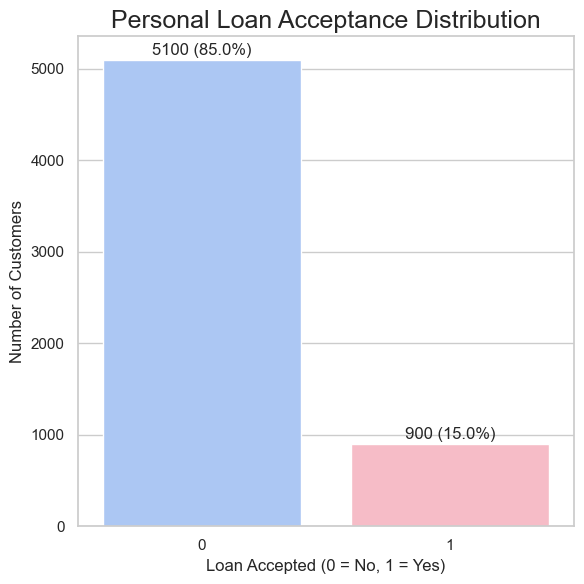

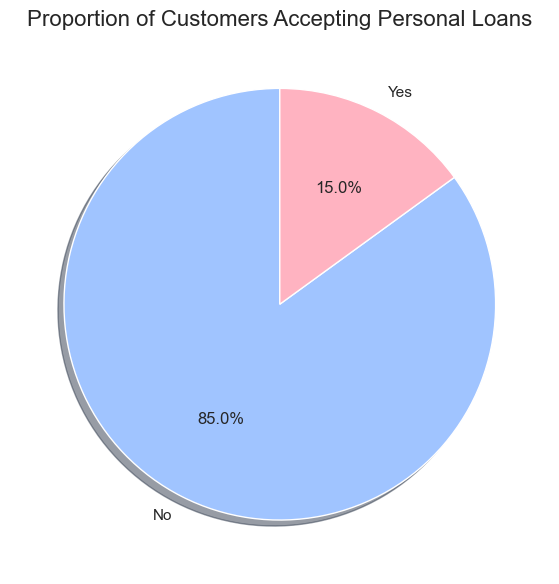

In [7]:
# 2.1 Understand the Target Variable – Loan Acceptance

print("\n- Target Variable Overview -")

# Value counts (absolute)
print("Counts:")
print(df['personal_loan'].value_counts())

# Value counts (percentage)
print("\nPercentages:")
print(df['personal_loan'].value_counts(normalize=True).mul(100).round(2))

# Visualise the class balance
plt.figure(figsize=(6, 6))
sns.countplot(x='personal_loan', data=df, palette=['#a0c4ff', '#ffb3c1'])
plt.title("Personal Loan Acceptance Distribution", fontsize=18)
plt.xlabel("Loan Accepted (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

# Add text annotations for clarity
counts = df['personal_loan'].value_counts()
for i, val in enumerate(counts):
    plt.text(i, val + 50, f"{val} ({val/len(df)*100:.1f}%)", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

# Optional: pie chart (for business perspectives)
plt.figure(figsize=(6,6))
plt.pie(
    df['personal_loan'].value_counts(),
    labels=['No', 'Yes'],
    autopct='%1.1f%%',
    colors=['#a0c4ff', '#ffb3c1'],
    startangle=90,
    shadow=True
)
plt.title("Proportion of Customers Accepting Personal Loans", fontsize=16)
plt.tight_layout()
plt.show()

**Interpretation**

Out of 6,000 customers, only **900 (15%) accepted** the personal loan, while **5,100 (85%) declined**, showing a **strong class imbalance**.  
This imbalance means models may over-predict the “No Loan” class, so techniques like **stratified sampling, resampling, or class weighting** should be used during modelling.

**Key takeaway**  
Loan acceptance is low (~15%), so understanding the characteristics of this minority group is essential for accurate prediction.

### 2.2 Univariate Analysis: Explore Each Variable Individually  

Examine each feature independently to understand its range, distribution, and overall behaviour.  
This helps detect skewness, outliers, and uneven category frequencies before studying relationships with the target variable.

We analyse:  
- **Continuous variables:** Age, Income, Experience, Mortgage, Credit Card Spend  
- **Categorical variables:** Education, Family Size, Account Ownership  

**Expected Outcome:**  
Clear visuals (histograms, boxplots, and bar charts) summarising each variable’s distribution and highlighting potential outliers or imbalanced categories.


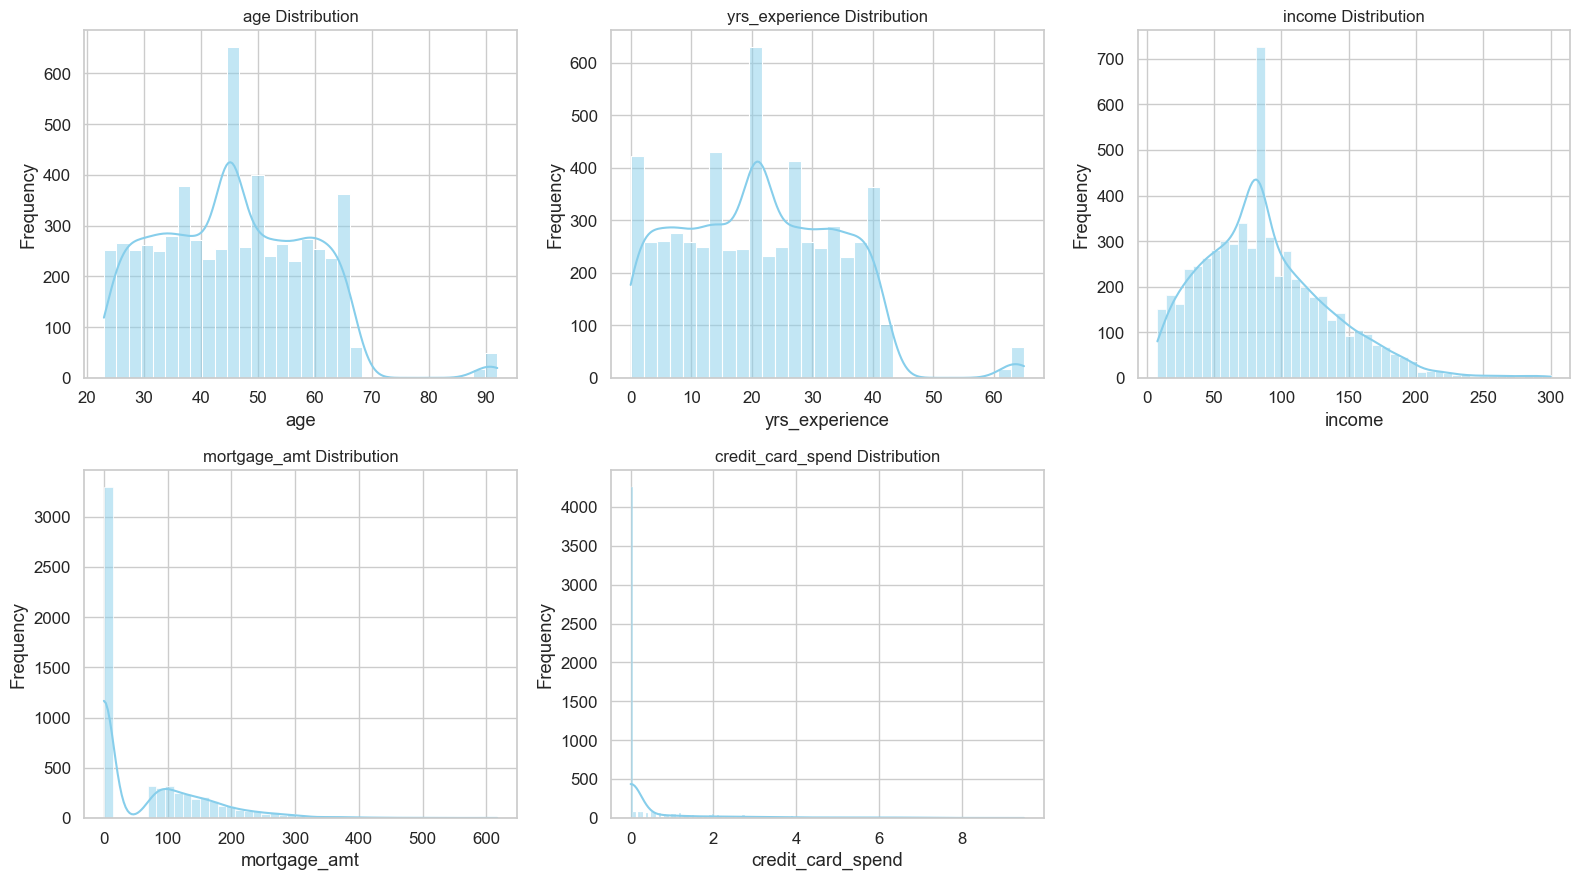

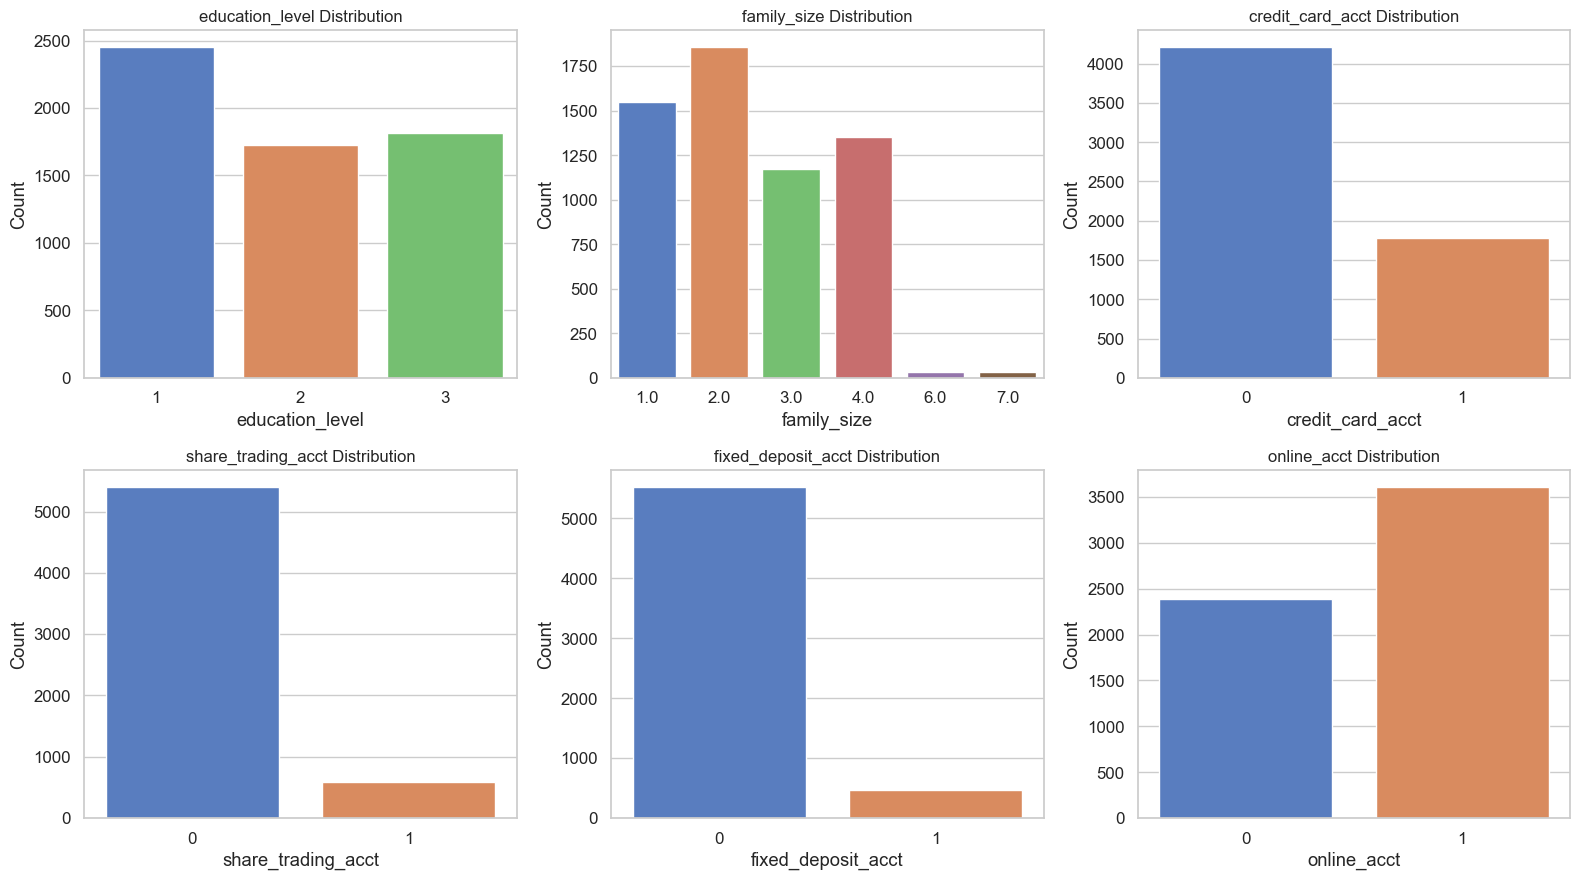

In [8]:
# 2.2 Univariate Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid", palette="pastel", font_scale=1.1)

# Define numeric and categorical columns
num_cols = ['age', 'yrs_experience', 'income', 'mortgage_amt', 'credit_card_spend']
cat_cols = ['education_level', 'family_size', 'credit_card_acct', 'share_trading_acct',
            'fixed_deposit_acct', 'online_acct']

# Continuous Variables 
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"{col} Distribution", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove extra subplot
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# Categorical Variables
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette="muted")
    axes[i].set_title(f"{col} Distribution", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Interpretation**

**Continuous:**  
- **Age** and **yrs_experience** are roughly bell-shaped around 45 and 20 years.  
- **Income** and **credit_card_spend** are strongly right-skewed, with most customers earning/spending modestly.  
- **Mortgage_amt** is zero-inflated, showing most customers hold no mortgage debt.

**Categorical:**  
- **Education_level:** Undergraduates dominate, followed by Graduates and Professionals.  
- **Family_size:** Mostly between 1–4, peaking at 2.  
- **Account ownership:** Online accounts are most common (around 60%), while credit card ownership (around 30%) is less frequent.  
  Share trading and fixed deposit accounts are least common.

**Summary:**  
The dataset mainly represents **digitally active, mid-income individuals** with low debt and moderate financial engagement.


### 2.3 Bivariate Analysis: Explore Relationships with Target  

Investigate how each predictor variable relates to the target (`personal_loan`).  
Compare numeric and categorical features across loan acceptance groups to uncover behavioural or financial patterns.

**Expected Outcome:**  
Visual and statistical evidence (e.g: boxplots, group means, cross-tabs) showing which customer traits are most strongly associated with accepting personal loans.


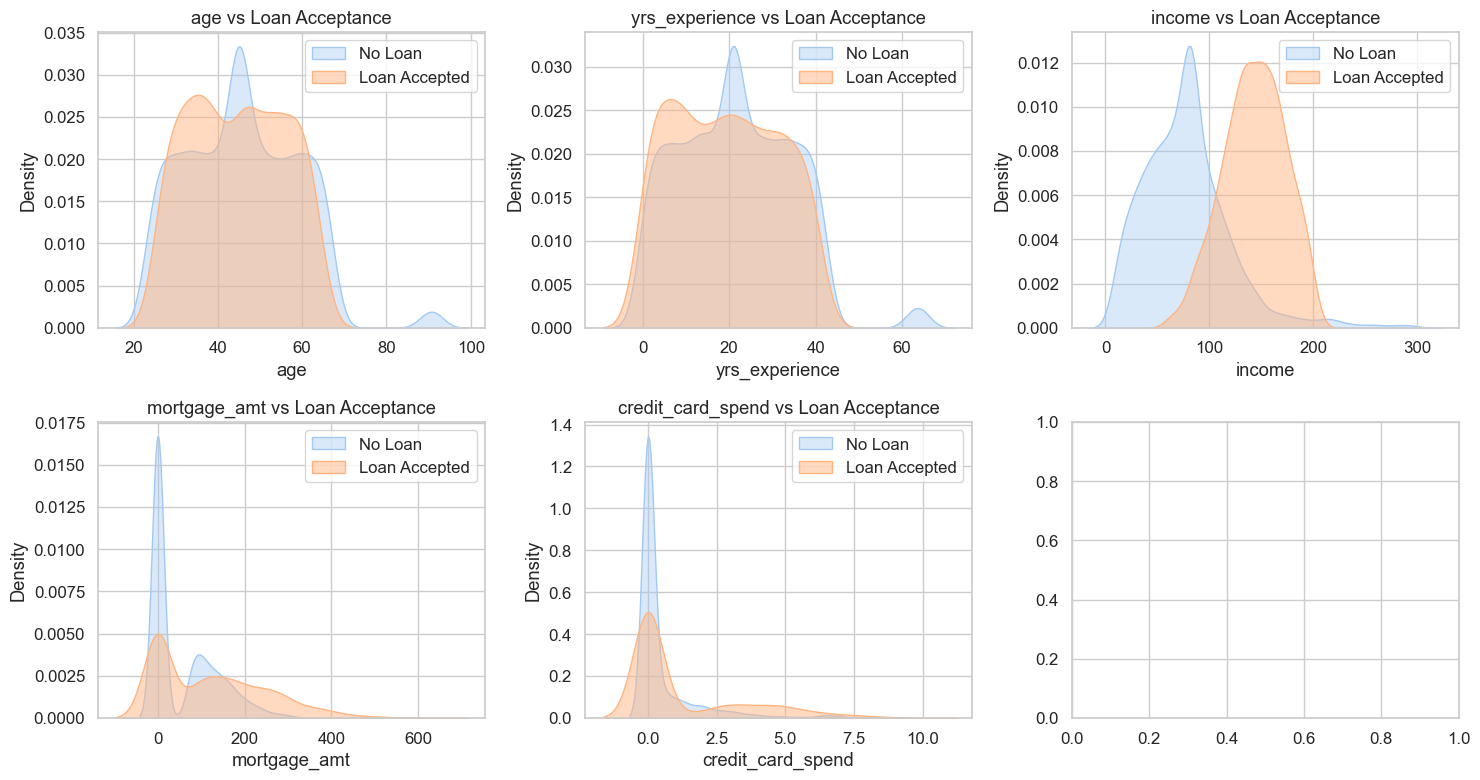

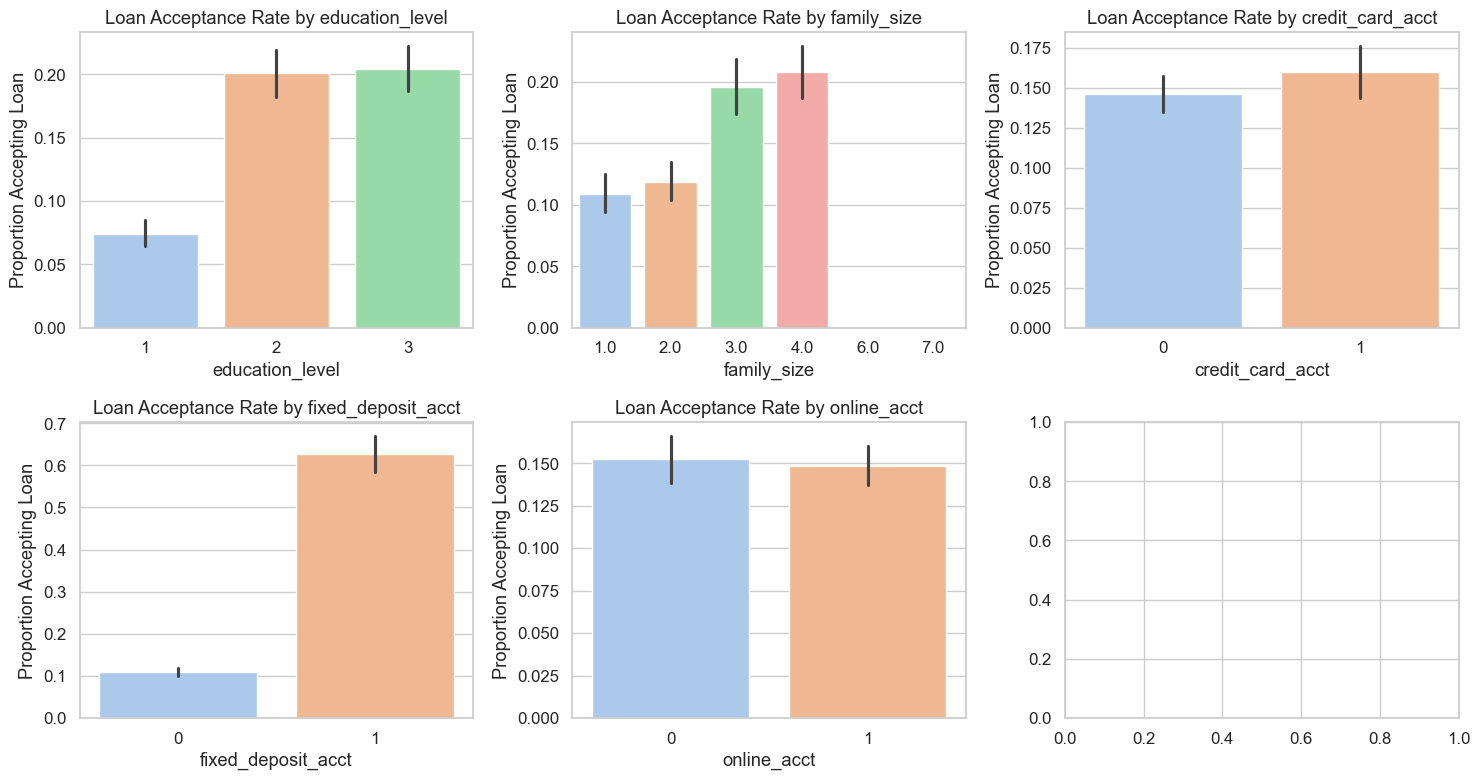

In [9]:
# 2.3 Explore Relationships with Target (Bivariate Analysis)

# Split target groups
loan_yes = df[df['personal_loan'] == 1]
loan_no = df[df['personal_loan'] == 0]

# Numeric Variables vs Target 
num_cols = ['age', 'yrs_experience', 'income', 'mortgage_amt', 'credit_card_spend']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=loan_no, x=col, fill=True, label="No Loan", alpha=0.4, ax=axes[i])
    sns.kdeplot(data=loan_yes, x=col, fill=True, label="Loan Accepted", alpha=0.5, ax=axes[i])
    axes[i].set_title(f"{col} vs Loan Acceptance")
    axes[i].legend()

plt.tight_layout()
plt.show()

# Categorical Variables vs Target
cat_cols = ['education_level', 'family_size', 'credit_card_acct', 'fixed_deposit_acct', 'online_acct']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.barplot(data=df, x=col, y='personal_loan', ax=axes[i], palette='pastel')
    axes[i].set_title(f"Loan Acceptance Rate by {col}")
    axes[i].set_ylabel("Proportion Accepting Loan")

plt.tight_layout()
plt.show()


**Interpretation**

**Continuous:**  
Higher **income** and **credit_card_spend** show strong association with loan acceptance, indicating that financially active or higher-spending customers are more receptive to loans.  
**Age**, **yrs_experience**, and **mortgage_amt** display weak or no visible relationship.

**Categorical:**  
Loan uptake increases with **education level** and **family size (3–4 members)**.  
Customers with **fixed deposit accounts** are significantly more likely to accept loans, while **online** and **credit card accounts** have minor effects.

**Summary:**  
Loan acceptance is primarily driven by **financial capacity and engagement**, rather than demographic characteristics.


# 3 Advanced Exploratory Data Analysis (EDA)  

### Purpose  
This phase extends beyond basic descriptive analysis to uncover **non-linear**, **hidden**, and **interaction-based** patterns within the data.  
It applies advanced techniques commonly used in professional analytics and modelling to reveal deeper behavioural and financial insights driving personal loan acceptance.

### Method  
1. **Spearman Correlation:** Measures monotonic (non-linear) relationships between numeric variables, complementing standard Pearson analysis.  
2. **Mutual Information Ranking:** Evaluates how much information each feature provides about the target, identifying strong predictors even without linear relationships.  
3. **Interaction Heatmaps:** Visualise how combinations of customer features (e.g.: income and spending) jointly affect loan acceptance rates.

### Outcome  
- Discovery of both linear and non-linear relationships between predictors and the target variable.  
- Identification of the most informative and influential customer attributes.  
- Visual insights into how feature interactions influence loan uptake, supporting advanced modelling and strategic targeting.


### 3.1 Correlation Analysis – Pearson vs Spearman (Advanced)  

**Concept:**  
Correlation measures how strongly two numeric variables move together.  
- **Pearson correlation** quantifies *linear* relationships, assuming normally distributed variables.  
- **Spearman correlation** evaluates *monotonic* relationships by ranking data — ideal for skewed or non-linear patterns.

**Why this method (Advanced):**  
Since financial and behavioural variables (e.g.: income, credit card spending) often follow **non-linear or non-normal distributions**, relying solely on Pearson may overlook real-world associations.  
Applying both correlation methods enables detection of subtle monotonic patterns that standard linear analysis cannot capture.  
This dual approach provides a **more comprehensive correlation map** between predictors and loan acceptance.

**Detailed Steps:**  
1. **Filter numerical columns:** Select only numeric variables for valid correlation computation.  
2. **Compute Pearson correlation matrix:** Captures *linear* dependencies among numeric features.  
3. **Compute Spearman correlation matrix:** Converts values into ranks to capture *monotonic non-linear* dependencies.  
4. **Visualise using heatmaps:** Two colour-coded matrices are plotted for easy comparison, with warm tones showing stronger associations.  
5. **Compare correlation with target (`personal_loan`):**  
   - Combine both Pearson and Spearman coefficients into a comparison table.  
   - Rank variables by their correlation strength with the target to identify top predictors.

**Expected Outcome:**  
- Two visual heatmaps highlighting linear vs non-linear relationships across variables.  
- A ranked comparison table showing how strongly each numeric variable (e.g., income, CCAvg, mortgage) correlates with `personal_loan`.  
- Identification of potential predictors for modelling and insight into which relationships are **linear** vs **monotonic** in nature.  

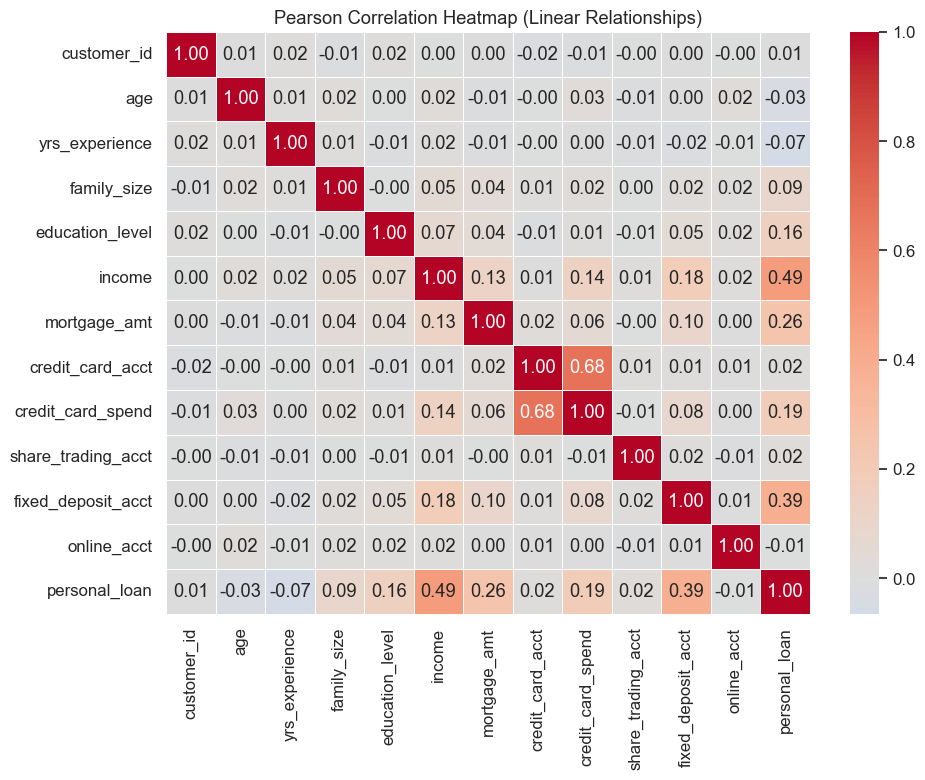

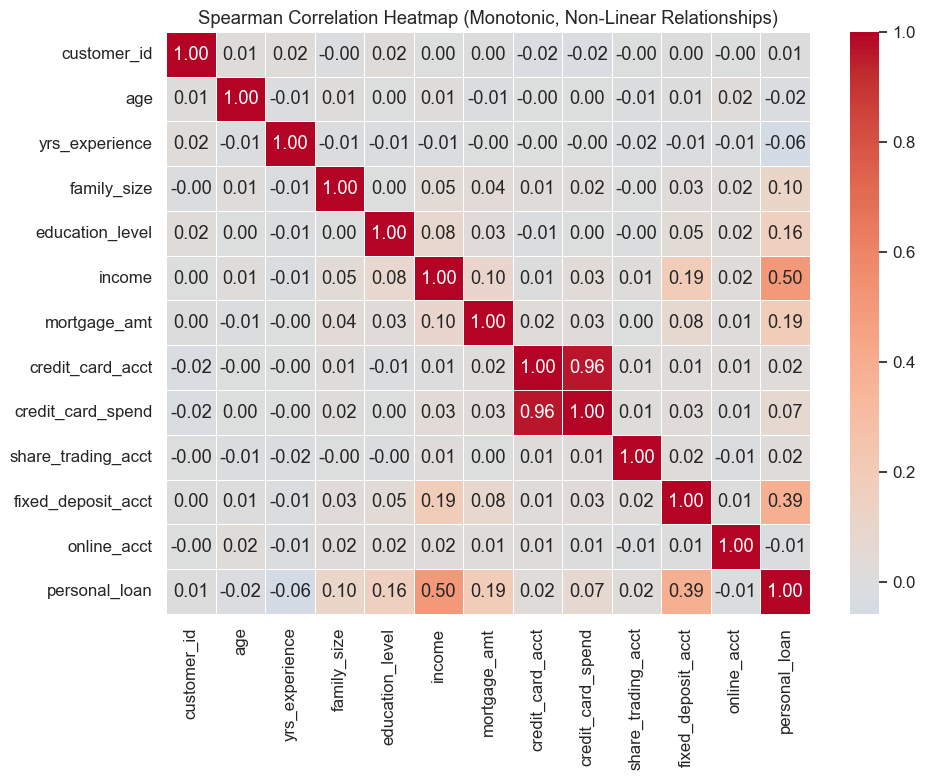


- Pearson vs Spearman Correlation with Target (personal_loan) -


,Pearson,Spearman
personal_loan,1.000,1.000
income,0.492,0.500
fixed_deposit_acct,0.389,0.389
mortgage_amt,0.259,0.191
education_level,0.159,0.162
family_size,0.089,0.103
credit_card_spend,0.189,0.067
share_trading_acct,0.020,0.020
credit_card_acct,0.018,0.018
customer_id,0.006,0.006


In [10]:
# 3.1 Correlation Analysis: Pearson vs Spearman 
# (linear vs monotonic non-linear)

# Select numeric columns only
num_cols = df.select_dtypes(include=['number']).columns

# Pearson (linear)
pearson_corr = df[num_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Pearson Correlation Heatmap (Linear Relationships)")
plt.tight_layout()
plt.show()

# Spearman (rank/monotonic)
spearman_corr = df[num_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Spearman Correlation Heatmap (Monotonic, Non-Linear Relationships)")
plt.tight_layout()
plt.show()

# Compare correlation with the target
target = 'personal_loan'
compare_target = (
    pd.DataFrame({
        'Pearson': pearson_corr[target],
        'Spearman': spearman_corr[target]
    })
    .sort_values('Spearman', ascending=False)
)

print("\n- Pearson vs Spearman Correlation with Target (personal_loan) -")
display(compare_target.style.format({'Pearson':'{:.3f}','Spearman':'{:.3f}'}).background_gradient(axis=None, cmap='Greens'))


### Interpretation  

Both correlation methods show similar ranking of key predictors, but Spearman provides a more reliable view of **non-linear trends**.  

- **Top predictors of loan acceptance:**  
  **Income (ρ ≈ 0.50)** and **Fixed Deposit Account (ρ ≈ 0.39)** have the strongest positive correlations, meaning higher income and existing deposits are linked to greater likelihood of taking a personal loan.  
  **Mortgage Amount** and **Education Level** show weaker, secondary associations.  

- **Negligible or no correlation:**  
  Age, experience, and online account usage have minimal influence, confirming that demographic factors are less relevant than financial behaviour.  

- **Pearson vs Spearman insight:**  
  Both show similar ordering, but Spearman slightly strengthens non-linear effects (income), capturing that loan likelihood increases with income up to a point and then plateaus.  

**Takeaway:**  
Loan acceptance is most influenced by **financial capacity and engagement**, not demographic characteristics — a pattern that supports targeted marketing toward higher-income, financially active clients.


### 3.2 Mutual Information Ranking

**Concept:**  
**Mutual Information (MI)** quantifies how much knowing one variable reduces uncertainty about another.  
Unlike correlation, which captures only *linear or monotonic* strength, MI detects **any type of dependency** — linear, non-linear, or categorical — making it valuable for mixed data types.

**Why this method (Advanced):**  
Correlation analysis measures how variables move together, but not how much they actually *inform* predictions.  
Mutual Information evaluates the **predictive contribution** of each feature to the target variable (`personal_loan`),  
revealing relationships that correlation may miss — for instance, stepwise or threshold effects common in financial behaviour.

**Detailed Steps:**  
1. **Encode categorical variables numerically** to prepare for MI computation.  
2. Apply `mutual_info_classif()` from `sklearn.feature_selection` to estimate MI between each predictor and `personal_loan`.  
3. Store and **rank features by their MI scores** to highlight those carrying the most predictive information.  
4. **Visualise the ranking** using a horizontal bar chart for easier comparison.  
5. Interpret and compare MI rankings with correlation results to identify variables that provide *additional non-linear insight*.

**Expected Outcome:**  
- A ranked feature-importance table or bar chart displaying MI scores for each variable.  
- Discovery of influential predictors that may not show strong correlation (e.g., education, family size).  
- A deeper understanding of **non-linear and categorical dependencies**, improving feature selection for modelling.


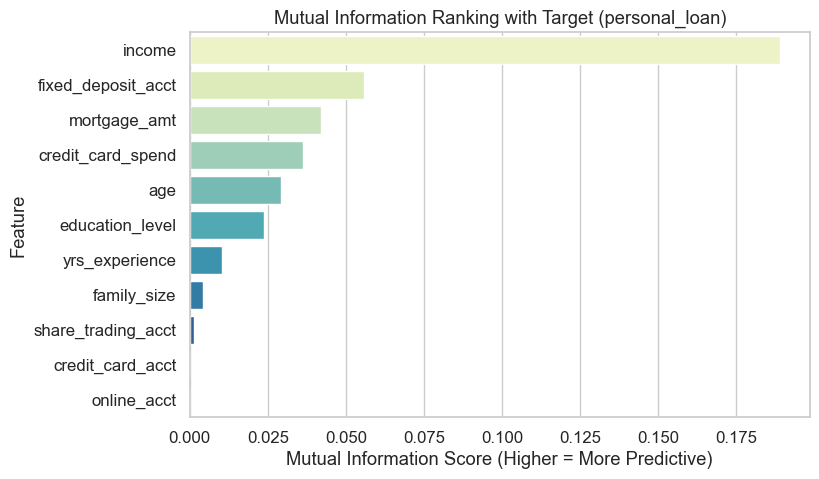

,Feature,Mutual_Information
4,income,0.189
9,fixed_deposit_acct,0.056
5,mortgage_amt,0.042
7,credit_card_spend,0.036
0,age,0.029
3,education_level,0.024
1,yrs_experience,0.010
2,family_size,0.004
8,share_trading_acct,0.001
6,credit_card_acct,0.000


In [11]:
# 3.2 Mutual Information Ranking

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler

# Select numeric and binary predictors (exclude ID and target)
X = df.drop(columns=['customer_id', 'personal_loan'])
y = df['personal_loan']

# Normalise numeric columns to keep fair scale
X_scaled = MinMaxScaler().fit_transform(X)

# Compute Mutual Information between each feature and the target
mi_scores = mutual_info_classif(X_scaled, y, random_state=42)

# Convert results into a dataframe for easy viewing
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Information': mi_scores
}).sort_values(by='Mutual_Information', ascending=False)

# Visualise top features
plt.figure(figsize=(8, 5))
sns.barplot(data=mi_df, x='Mutual_Information', y='Feature', palette='YlGnBu')
plt.title('Mutual Information Ranking with Target (personal_loan)')
plt.xlabel('Mutual Information Score (Higher = More Predictive)')
plt.ylabel('Feature')
plt.show()

# Display numeric summary
display(mi_df)


### Interpretation  

The mutual information (MI) analysis reveals that **Income (0.189)** is by far the most informative variable for predicting loan acceptance.  
**Fixed Deposit Account (0.056)** and **Mortgage Amount (0.042)** also contribute moderate predictive value, reflecting that customers with higher financial assets or collateral are more likely to take a personal loan.  

**Credit Card Spend**, **Age**, and **Education Level** provide smaller but non-negligible information gains, while demographic features such as **Family Size**, **Experience**, and **Online Account** have near-zero MI scores.  

**Takeaway:**  
Mutual Information confirms that **financial engagement and capacity**, rather than basic demographics, drive loan acceptance decisions.  
This method uncovers hidden non-linear relationships that standard correlation alone cannot detect.


### 3.3 Interaction Heatmaps (Advanced Bivariate Relationships)

**Concept:**  
Visualise how **pairs of features** jointly influence loan acceptance.  
By binning continuous variables and averaging the target within each 2D bin, we reveal **conditional patterns** that single-variable views and simple correlations can miss.

**Why this method (Advanced):**  
Financial behaviour is often **non-linear and conditional** (e.g., high credit spending only signals interest among high-income customers).  
Interaction heatmaps expose these **segment-level effects** to guide targeting and feature engineering.

**Detailed Steps:**  
1. **Quantile binning with safeguards:**  
   - Use a helper `qbin()` to create **q-quantile bins** (default 5: *Very Low → Very High*).  
   - Handles duplicate quantiles (e.g., many zeros) via `duplicates='drop'` and auto-adjusted labels.  
2. **Ensure numeric target:**  
   - Map `personal_loan` to **0/1** so that group **mean × 100 = acceptance rate (%)**.  
3. **Build 2D grids (groupby–mean):**  
   - For each feature pair, compute `groupby([binA, binB])['personal_loan'].mean() * 100`, then `unstack()` to form a matrix.  
4. **Plot heatmaps with annotations:**  
   - Use `sns.heatmap(..., annot=True)` to show **acceptance rate (%)** in each cell.  
   - Titles/axes clearly specify bin definitions and feature meanings.

**Implemented Grids & Hypotheses:**  
- **A) Income × Credit Card Spend** (5×5 quantile bins)  
  *Hypothesis:* Highest acceptance where both **Income** and **CCAvg** are high.  
- **B) Income × Education Level** (Income binned; Education ordered 1–3)  
  *Hypothesis:* Higher education **amplifies** income’s positive effect.  
- **C) Income × Family Size** (Income binned; Family discrete)  
  *Hypothesis:* Mid-sized families (3–4) may show higher propensity than singles or very large families.

**Expected Outcome:**  
Three annotated heatmaps showing **loan acceptance rate (%)** by feature pairs, revealing **high-potential customer segments** (e.g.: *High Income × High Spend*).  
These insights inform **segmented targeting** and **feature engineering** (e.g.: interaction terms or non-linear transformations) for modelling.


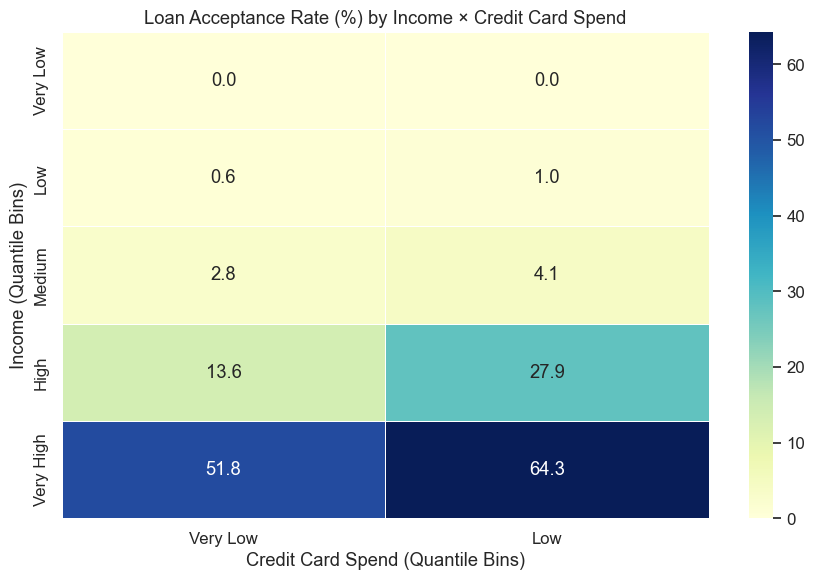

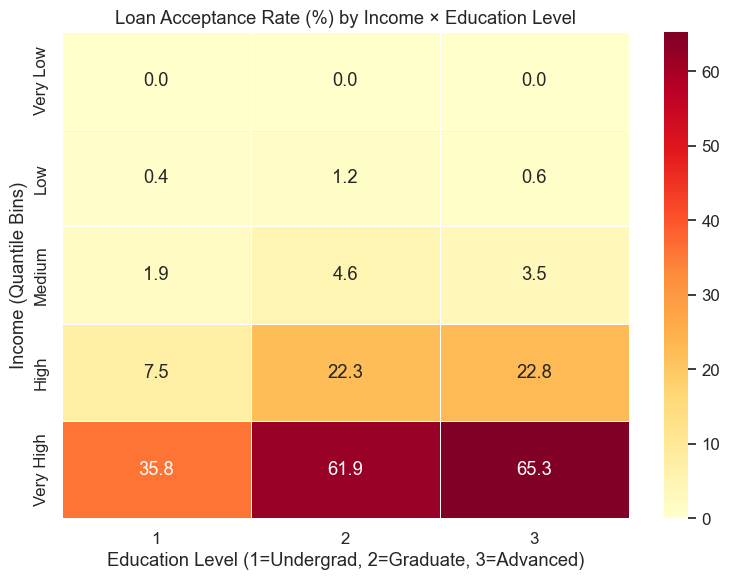

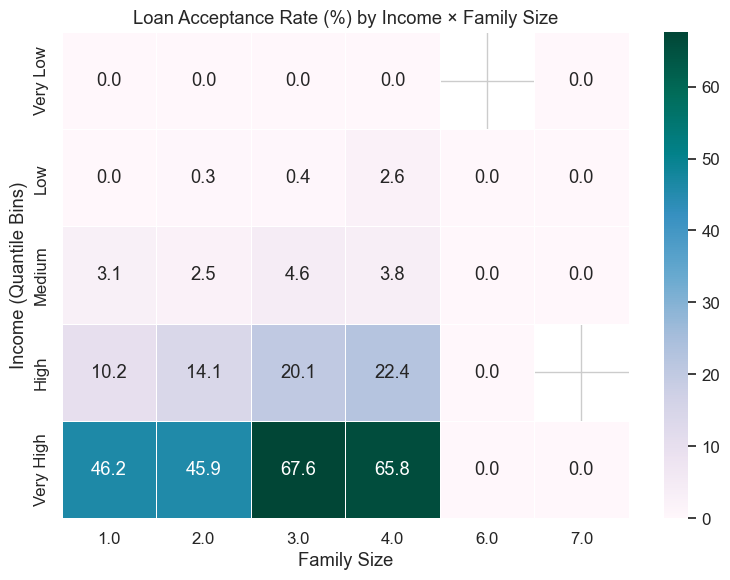

In [12]:
# 3.3 Interaction Heatmap
# Goal: Examine how two features together influence personal loan acceptance.
# This reveals interaction effects that single-variable analysis might miss.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Helper function for safe quantile binning 
# Automatically adjusts the number of bins if duplicate quantiles occur (e.g., many zeros)
def qbin(series, q=5, base_labels=('Very Low','Low','Medium','High','Very High')):
    binned = pd.qcut(series, q=q, duplicates='drop')
    valid_labels = list(base_labels)[:binned.cat.categories.size]
    return binned.cat.rename_categories(valid_labels)

# Ensure target variable is numeric
# This enables averaging (mean) to compute loan acceptance rates by group.
if df['personal_loan'].dtype not in ['int64', 'float64']:
    df['personal_loan'] = df['personal_loan'].map({'yes': 1, 'no': 0}).astype(int)


# A) Income × Credit Card Spend
# Hypothesis: Customers with both high income and high spending habits are more likely to accept personal loans.

income_bin = qbin(df['income'], q=5)
cc_bin = qbin(df['credit_card_spend'], q=5)

grid_a = (
    df.assign(income_bin=income_bin, cc_bin=cc_bin)
      .groupby(['income_bin', 'cc_bin'])['personal_loan']
      .mean().mul(100).unstack().round(1)
)

plt.figure(figsize=(9,6))
sns.heatmap(grid_a, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)
plt.title("Loan Acceptance Rate (%) by Income × Credit Card Spend")
plt.xlabel("Credit Card Spend (Quantile Bins)")
plt.ylabel("Income (Quantile Bins)")
plt.tight_layout()
plt.show()


# B) Income × Education Level
# Hypothesis: Education may amplify income’s influence on loan uptake, as higher-educated customers often have more financial confidence.

income_bin_b = qbin(df['income'], q=5)

grid_b = (
    df.assign(income_bin=income_bin_b)
      .groupby(['income_bin', 'education_level'])['personal_loan']
      .mean().mul(100).unstack().round(1)
)

plt.figure(figsize=(8,6))
sns.heatmap(grid_b, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
plt.title("Loan Acceptance Rate (%) by Income × Education Level")
plt.xlabel("Education Level (1=Undergrad, 2=Graduate, 3=Advanced)")
plt.ylabel("Income (Quantile Bins)")
plt.tight_layout()
plt.show()


# C) Income × Family Size
# Hypothesis: Families with moderate size (e.g., 3–4) may be more loan-prone due to household expenses, compared to singles or very large families.

income_bin_c = qbin(df['income'], q=5)

grid_c = (
    df.assign(income_bin=income_bin_c)
      .groupby(['income_bin', 'family_size'])['personal_loan']
      .mean().mul(100).unstack().round(1)
)

plt.figure(figsize=(8,6))
sns.heatmap(grid_c, annot=True, fmt=".1f", cmap="PuBuGn", linewidths=0.5)
plt.title("Loan Acceptance Rate (%) by Income × Family Size")
plt.xlabel("Family Size")
plt.ylabel("Income (Quantile Bins)")
plt.tight_layout()
plt.show()


### **Interpretation**

**Income × Credit Card Spend**  
Loan acceptance rises sharply among **high-income customers with high spending**, exceeding **60%**.  
Low-income groups show minimal interest even with higher spending, implying affordability is a stronger driver than lifestyle activity.

**Income × Education Level**  
Acceptance increases with both **income and education level**.  
Highly educated, high-income clients show rates above **60%**, suggesting trust, stability, and eligibility are key factors.

**Income × Family Size**  
Loan uptake peaks among **high-income families of 3–4 members** (~65%).  
These groups may be borrowing for education, housing, or family development, while very small or very large families show lower rates.


**Key Takeaway:**  
Loan acceptance is strongest among **affluent, educated, and financially active customers**.  
These combined insights reveal where banks should **focus future marketing** and which interaction terms could enhance **predictive model performance**.

## 4. Summary & Insights

The dataset includes **6,000 customers** with **13 features** on demographics, income, spending, and account ownership.  
Only **15%** accepted the personal loan → confirming a **highly imbalanced target**.

**Main Patterns Identified**
- **Income** and **Fixed Deposit Account** have the strongest positive link with loan acceptance.  
- **Mortgage Amount** and **Credit Card Spend** also influence acceptance, while **Age** and **Experience** show weaker effects.  
- **Education Level** and **Family Size** moderately shape behaviour — graduates and mid-sized families accept loans more often.  
- **High Income + High Spending** customers form the most receptive segment.  
- Outliers in *Income* and *Credit Card Spend* are genuine wealthy clients and should be retained.  
- Correlations reveal potential overlap between `credit_card_acct` and `credit_card_spend`, which may need monitoring during modelling.  

**Technical Insights**
- **Spearman correlation** captured non-linear relationships (especially Income ↔ Loan).  
- **Mutual Information** highlighted `income`, `fixed_deposit_acct`, and `mortgage_amt` as top predictors.  
- **Interaction analysis** confirmed that combining high income with education or spending increases loan uptake.